# 13 · 직접 쓴 미분을 자동미분 그래프로 연결하기

**이번 질문:** 지금까지 층마다 손으로 쓴 backward를, 연산마다의 국소 미분만 적어 두면 기계가 알아서 이어 주게 할 수 있을까요? 그렇게 만든 기울기가 손으로 쓴 것, PyTorch, 중심차분과 같을까요?

NumPy 배열을 담는 작은 `Node`를 만들고, 연산의 국소 미분(VJP)을 연결해 MLP를 학습합니다. 같은 가중치에서 손으로 쓴 backward·이 엔진·PyTorch·중심차분을 비교합니다.
핵심 코드는 모두 본문에 있습니다.

- 준비물: [01](../00_기초/01_gradients_and_learning.ipynb)의 연쇄법칙, [03](../00_기초/03_perceptron_to_mlp.ipynb)의 MLP backward, [08](../01_아키텍처/08_attention.ipynb)의 Jacobian.
- 도착점: VJP·broadcast 역방향·위상 순서를 직접 쓰고, 새 연산을 그래프에 붙여 전체 MLP 검산을 통과시킵니다.
- 다음 연결: [14 손실·정규화](14_losses_regularization.ipynb)에서는 계산할 목적을 바꿉니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 자동미분은 연산마다 "뒤에서 온 기울기 $g$를 입력 쪽으로 옮기는 규칙" $dx=J^\top g$(VJP)만 알면 됩니다. 전체 Jacobian은 만들지 않습니다. 같은 값이 여러 경로에 쓰였으면 기여를 **더합니다**.
2. broadcasting의 역방향은 합입니다. $(D,)$를 $(N,D)$로 복사해 썼으면 `dY.sum(axis=0)`, 길이 1이던 축은 `keepdims=True`로 합칩니다.
3. `Node`는 값·부모·pullback을 들고, 위상 순서(부모 먼저)를 뒤집어 backward를 돕니다. 스텝마다 그래프를 새로 만들고, backward 뒤에 파라미터를 갱신합니다. PyTorch는 `.grad`를 누적하므로 `zero_grad`가 필요합니다.

📎 이 단원의 PyTorch 비교 셀은 CPU의 `float64`를 사용합니다. 프로젝트 최상위에서 `python -m pip install -e '.[dev,framework]'`로 실행 환경을 준비할 수 있습니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/autodiff_plots.py)

In [1]:
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/utils/plotting.py').is_file())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
import torch
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.utils.autodiff_plots import (
    plot_curves, plot_shared_path, plot_vjp, plot_broadcast_backward, plot_mlp_graph, plot_local_rules,
    plot_training_cycle, plot_fit, plot_stop_gradient,
)
setup_plots()
print('NumPy:', np.__version__, 'PyTorch:', torch.__version__, '비교 장치: CPU, dtype: float64')

NumPy: 2.3.5 PyTorch: 2.11.0+cu130 비교 장치: CPU, dtype: float64


### 📎 이 노트북의 예시: 손계산 그래프, 작은 MLP, sin 회귀

- **손계산 그래프.** $u=x^2$, $y=u+u$처럼 같은 값이 두 경로에 쓰이는 작은 그래프와 2×2 Jacobian.
- **작은 MLP.** 입력 3, 은닉 4, 출력 2의 MLP 한 개. 손으로 쓴 backward·엔진·PyTorch·중심차분을 같은 가중치에서 비교합니다.
- **sin 회귀.** $y=\sin(\pi x)+$잡음 64점을 엔진으로 학습합니다. MNIST는 쓰지 않습니다. 계산 그래프는 작은 도식이 더 잘 보이기 때문입니다.

## 🔑 1. 자동미분이 연결하는 것은 국소 변화율입니다

**이 절에서 가져갈 것:** 연산 하나는 "출력 쪽 기울기 $g$를 받아 입력 쪽 기울기 $J^\top g$를 돌려주는" 국소 규칙만 알면 됩니다. 이 규칙을 그래프의 역순으로 이으면 전체 미분이고, 같은 값을 여러 곳에서 썼으면 각 경로의 기여를 더합니다.

$x=3$에서 $u=x^2$을 만들고 $y=u+u$를 계산한다고 합시다. $y$를 $x$로 미분하려면 $y\to u$의 변화율 2와 $u\to x$의 변화율 $2x=6$을 곱하면 12입니다. 여기서 "2"는 $u$가 두 경로로 쓰여 $1+1$이 된 것입니다.

> **용어**
>
> - **국소 미분(local derivative)**: 연산 하나의 출력을 그 연산의 입력으로 미분한 값. 전체 그래프를 몰라도 그 연산만 보고 적을 수 있습니다.
> - **VJP(vector-Jacobian product)** $dx=J^\top g$: 출력 쪽 기울기 $g$에 Jacobian의 전치를 곱해 입력 쪽 기울기를 얻는 것. 행렬 $J$를 만들지 않고 곱만 계산합니다.
> - **계산 그래프(computational graph)**: 값(노드)과 연산(화살표)을 그린 것. 순전파는 화살표 방향, 역전파는 거꾸로 갑니다.

계산 $u=x^2$, $y=u+u$에서 $dy/du=2$, $du/dx=2x$이므로 $dy/dx=4x$입니다.
$x=3$이면 $u=9$, $y=18$, $dy/dx=12$입니다. 같은 $u$를 두 경로에서 사용했으므로 그 지점의 기울기는 두 기여의 **합**입니다.

일반적으로 $y=f(x)$가 벡터일 때 $J_{ij}=\partial y_i/\partial x_j$를 Jacobian이라 합니다.
뒤에서 $g_i=\partial L/\partial y_i$가 오면

$$\frac{\partial L}{\partial x_j}=\sum_i g_iJ_{ij},\qquad d x=J^Tg.$$

입력 $x_j$의 기울기는 그 입력이 영향을 준 모든 출력 $y_i$의 기울기 $g_i$에 변화율 $J_{ij}$를 곱해 더한 것입니다.

이를 **VJP(vector–Jacobian product)** 라고 부릅니다. 열벡터 규약의 $J^Tg$는 행벡터 규약에서 $g^TJ$입니다.
전체 Jacobian을 저장하는 대신 연산마다 이 곱을 계산합니다. 스칼라 손실은 시작값 $dL/dL=1$을 사용하고, 벡터 출력은 목적을 정하는 가중치 $g$를 전달합니다.

아래는 $u=x^2$, $y=u+u$의 그래프에 국소 미분을 적은 것입니다.

In [2]:
path_x = 3.
path_u = path_x ** 2                                                  # 9
path_y = path_u + path_u                                              # 18
path_du_dx = 2 * path_x                                               # 국소 미분 6
path_dy_du_each = [1., 1.]                                            # u 가 쓰인 두 경로의 국소 미분
path_dx = sum(path_dy_du_each) * path_du_dx                           # (1 + 1) · 6 = 12
print("u =", path_u, "· y =", path_y, "· dy/dx =", path_dx)

u = 9.0 · y = 18.0 · dy/dx = 12.0


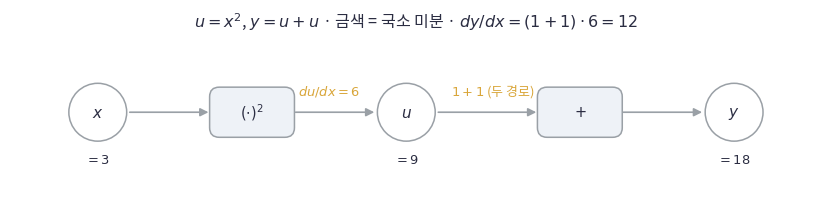

In [3]:
plot_shared_path(path_x, path_u, path_y, path_du_dx, path_dy_du_each, path_dx)

🔍 **확인** · $y$에서 $u$로 돌아오는 기울기는 두 화살표 각각 1이라 합이 2입니다. $u$에서 $x$로는 국소 미분 6을 곱해 12입니다. 자동미분은 이 두 가지, 즉 **국소 미분을 곱하고 같은 노드로 오는 기여를 더하는 것**만 반복합니다.

### 🔍 작은 Jacobian으로 VJP 확인하기

$y=(x_0x_1,\ x_0+x_1^2)$의 $2\times2$ Jacobian을 손으로 쓰고, 출력 쪽 기울기 $g$와 곱해 입력 쪽 기울기를 얻습니다.

In [4]:
# 작은 Jacobian을 실제로 써서 VJP와 내적 목적의 미분을 비교합니다.
x_hand = np.array([2., 3.])
J_hand = np.array([[x_hand[1], x_hand[0]], [1., 2*x_hand[1]]])  # y=(x0*x1, x0+x1**2)
g_hand = np.array([.5, -2.])
vjp_hand = J_hand.T @ g_hand
np.testing.assert_allclose(vjp_hand, [-.5, -11.])
print('J.T @ g:', vjp_hand)

J.T @ g: [ -0.5 -11. ]


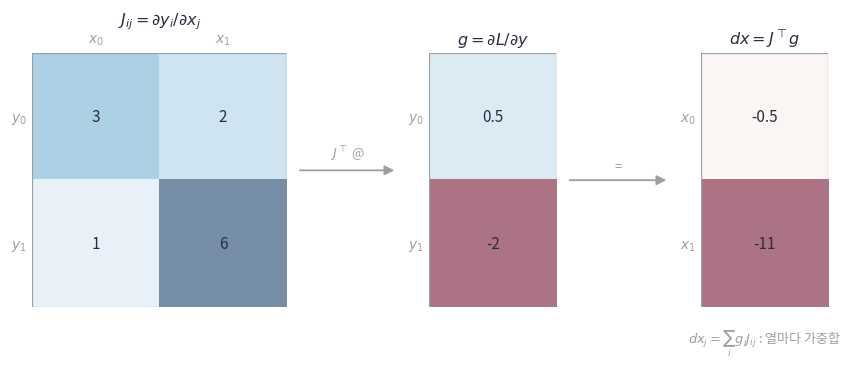

In [5]:
plot_vjp(J_hand, g_hand, vjp_hand, ["$y_0$", "$y_1$"], ["$x_0$", "$x_1$"])

🔍 **확인** · $dx_0=g_0J_{00}+g_1J_{10}=0.5\cdot3+(-2)\cdot1=-0.5$처럼 $J$의 **열**마다 $g$로 가중합합니다. $J^\top g$가 그 계산입니다. 아래 엔진의 각 연산은 이 곱을 $J$ 없이 바로 씁니다.

## 🔑 2. broadcasting의 역방향은 합치기입니다

**이 절에서 가져갈 것:** 작은 배열을 복사해 큰 배열과 계산했으면, 역방향에서는 복사된 자리로 온 기울기를 **모두 더해** 원래 모양으로 돌려줍니다. 앞에 추가된 축은 합하고, 길이 1이던 축은 `keepdims=True`로 합합니다.

$Y=X+b$에서 $b$ $(D,)$는 $N$개 행에 똑같이 더해졌습니다. $b_j$가 $N$번 쓰였으니 $b_j$의 기울기는 그 $N$개 자리의 기울기를 더한 것입니다. 1절의 "같은 값이 여러 경로에 쓰이면 더한다"와 같은 일입니다.

> **용어** · **broadcasting 역방향(`sum_to_shape`)**: 기울기 $(N,D)$를 원래 모양 $(D,)$나 $(N,1)$로 줄이는 합. 코드에서는 앞 축은 `sum(axis=0)`, 길이 1 축은 `sum(axis=k, keepdims=True)`.

$Y=X+b$에서 $X:(N,D)$, $b:(D,)$이면 $b_j$가 $N$번 쓰입니다.
따라서 $db_j=\sum_n dY_{nj}$입니다. `(N,1)`을 `(N,D)`로 확장했다면 열을 합해야 합니다.
앞에 추가된 축을 합하고, 원래 길이가 1이었던 축을 길이 1로 남기며 합하면 원래 shape의 기울기를 얻습니다.
`keepdims=True`는 합한 축의 길이를 1로 유지합니다.

In [6]:
bc_b = np.array([3., 4., 5.])                                         # (D=3,)
bc_expanded = np.broadcast_to(bc_b, (2, 3))                           # forward: (N=2, D) 로 복사
bc_upstream = np.arange(1., 7.).reshape(2, 3)                         # (2, 3) 뒤에서 온 기울기 dY
bc_db = bc_upstream.sum(axis=0)                                       # (3,) 복사한 자리를 더함
print("복사\n", bc_expanded, "\ndY\n", bc_upstream, "\ndb =", bc_db)

복사
 [[3. 4. 5.]
 [3. 4. 5.]] 
dY
 [[1. 2. 3.]
 [4. 5. 6.]] 
db = [5. 7. 9.]


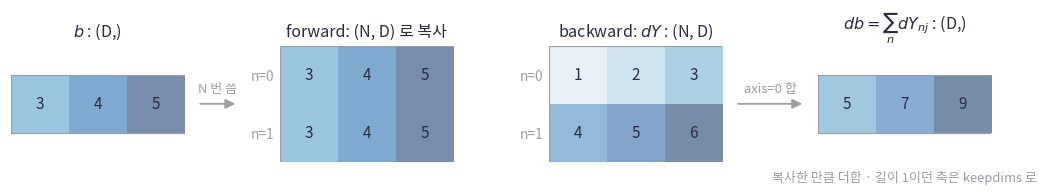

In [7]:
plot_broadcast_backward(bc_b, bc_expanded, bc_upstream, bc_db)

🔍 **확인** · $b$의 첫 원소 3은 두 행에 모두 쓰였으므로 그 자리의 기울기 1과 4를 더한 5가 $db_0$입니다. 아래 구현은 일반 모양에 대해 앞 축과 길이 1 축을 차례로 합칩니다.

In [8]:
def sum_to_shape(gradient, original_shape):
    g = np.asarray(gradient)
    while g.ndim > len(original_shape):
        g = g.sum(axis=0)
    for axis, size in enumerate(original_shape):
        if size == 1:
            g = g.sum(axis=axis, keepdims=True)
    return g.reshape(original_shape)

In [9]:
upstream = np.arange(1., 7.).reshape(2, 3)
np.testing.assert_allclose(sum_to_shape(upstream, (3,)), [5., 7., 9.])
np.testing.assert_allclose(sum_to_shape(upstream, (2, 1)), [[6.], [15.]])
np.testing.assert_allclose(sum_to_shape(upstream, ()), 21.)
print('broadcast 역방향: 열별 / 행별 / 전체 합 검산')
np.testing.assert_allclose(sum_to_shape(bc_upstream, (3,)), bc_db)   # 위 그림의 db

broadcast 역방향: 열별 / 행별 / 전체 합 검산


🔍 **확인** · 열별 합 `[5, 7, 9]`, 행별 합 `[[6], [15]]`, 전체 합 21이 각각 $(D,)$, $(N,1)$, $()$ 모양의 기울기입니다.

## 🔑 3. Node: 값·부모·국소 backward 보관하기

**이 절에서 가져갈 것:** `Node`는 값(`data`), 기울기(`grad`), 입력 노드들(`parents`), 그리고 뒤에서 온 기울기를 부모에게 더해 주는 함수(`pullback`) 넷을 들고 있습니다. backward는 부모를 먼저 방문하는 위상 순서를 만든 뒤 거꾸로 돌며 각 pullback을 한 번씩 부릅니다.

> **용어**
>
> - **pullback**: 출력 쪽 기울기 $g$를 받아 각 부모의 `grad`에 $J^\top g$를 **더하는** 함수. 연산마다 하나씩 만들어 출력 Node에 붙입니다.
> - **위상 순서(topological order)**: 모든 입력이 그것을 쓰는 연산보다 앞에 오는 순서. 뒤집으면 "출력부터 입력으로"가 되어 backward 순서가 됩니다.
> - **closure**: 함수 안에서 만든 함수가 바깥 변수(부모 노드, 순전파 값)를 기억하는 것. 아래 `back` 함수가 그렇게 부모를 기억합니다.

`Node.data`는 순전파 값, `Node.grad`는 그 값에 대한 손실의 기울기입니다. `parents`는 입력 Node들의 tuple이며, `pullback`은 뒤에서 온 기울기를 부모에게 더하는 함수입니다.
클래스의 `__add__`, `__mul__`, `__matmul__`은 Python이 `+`, `*`, `@`를 실행할 때 부르는 메서드입니다. 아래에서 정의할 연산 함수로 연결합니다.

**위상 순서**는 각 입력이 그 입력을 사용하는 연산보다 먼저 오는 순서입니다.
부모를 먼저 방문하고 자신을 목록에 추가한 뒤 목록을 뒤집으면 역전파 순서가 됩니다.
같은 Node는 한 번만 목록에 넣되, 모든 사용 경로의 기울기를 `+=`로 모읍니다.

이 교육용 엔진은 매 `backward` 호출마다 도달 가능한 Node의 기울기를 0으로 만들고 새로 계산합니다.
파라미터 갱신은 그 그래프의 backward가 끝난 뒤 수행하며, 다음 스텝에서 순전파 그래프를 새로 만듭니다.

아래는 4절에서 쓸 MLP 손실의 계산 그래프와 위상 순서입니다.

In [10]:
mlp_order = ["X", "W1", "op:mm1", "b1", "op:add1", "op:tanh", "W2", "op:mm2", "b2", "op:add2", "Y", "op:sub", "op:sq", "op:mean", "L"]
print("위상 순서 (부모가 먼저):", " → ".join(mlp_order))
print("backward 순서:", " → ".join(reversed(mlp_order)))

위상 순서 (부모가 먼저): X → W1 → op:mm1 → b1 → op:add1 → op:tanh → W2 → op:mm2 → b2 → op:add2 → Y → op:sub → op:sq → op:mean → L
backward 순서: L → op:mean → op:sq → op:sub → Y → op:add2 → b2 → op:mm2 → W2 → op:tanh → op:add1 → b1 → op:mm1 → W1 → X


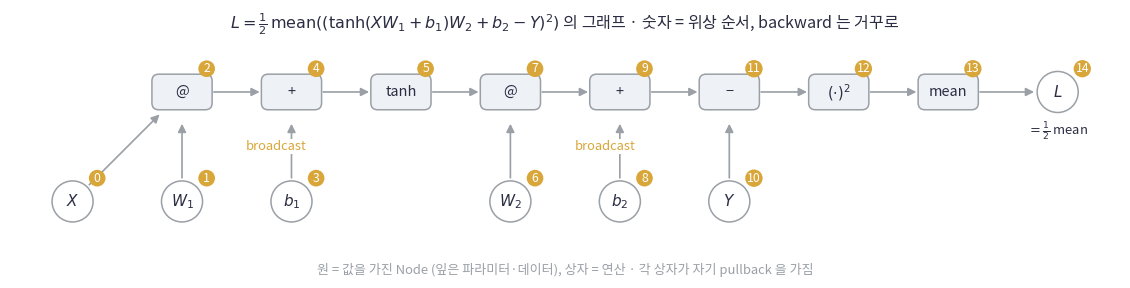

In [11]:
plot_mlp_graph(mlp_order)

🔍 **확인** · 잎(입력·파라미터·정답)은 부모가 없고, 연산 상자는 부모의 값으로 자기 값을 만듭니다. 금색 번호가 위상 순서이며 어떤 상자도 자기 부모보다 앞에 오지 않습니다. backward는 $L$부터 이 번호를 거꾸로 돌며 상자마다 pullback을 부릅니다.
아래 구현이 `Node` 클래스입니다. `backward`가 방문·순서·초기화·pullback 호출을 모두 담당합니다.

In [12]:
class Node:
    def __init__(self, data, parents=(), pullback=None):
        self.data = np.array(data, dtype=float, copy=True)
        self.grad = np.zeros_like(self.data)
        self.parents = tuple(parents)
        self.pullback = pullback

    def backward(self, seed=None):
        order, visited = [], set()
        def visit(node):
            if node in visited:
                return
            visited.add(node)
            for parent in node.parents:
                visit(parent)
            order.append(node)
        visit(self)
        if seed is None:
            if self.data.shape != ():
                raise ValueError('벡터 출력에는 같은 shape의 seed를 전달합니다.')
            seed = np.ones_like(self.data)
        seed = np.asarray(seed, dtype=float)
        if seed.shape != self.data.shape:
            raise ValueError('seed와 출력의 shape를 맞춥니다.')
        for node in order:
            node.grad = np.zeros_like(node.data)
        self.grad = seed.copy()
        for node in reversed(order):
            if node.pullback is not None:
                node.pullback(node.grad)

    def __add__(self, other):
        return add(self, other)

    def __radd__(self, other):
        return add(other, self)

    def __mul__(self, other):
        return multiply(self, other)

    def __rmul__(self, other):
        return multiply(other, self)

    def __neg__(self):
        return multiply(self, -1.)

    def __sub__(self, other):
        return add(self, -as_node(other))

    def __matmul__(self, other):
        return matmul(self, other)

    def tanh(self):
        return tanh(self)

    def sum(self):
        return total_sum(self)

    def mean(self):
        return total_sum(self) * (1. / self.data.size)


def as_node(value):
    return value if isinstance(value, Node) else Node(value)

### 🔑 국소 규칙을 코드로 넣기

**이 절에서 가져갈 것:** 연산마다 pullback 한 줄씩입니다. 덧셈은 $g$를 그대로, 곱셈은 상대 입력을 곱해서, 행렬곱은 전치를 곱해서, tanh는 $(1-y^2)$를 곱해서 부모에게 더합니다. broadcasting이 있었으면 `sum_to_shape`로 줄입니다.

$Y=A+B$: $dA=G$, $dB=G$, 각 원래 shape로 합칩니다.

$Y=A\odot B$: $dA=G\odot B$, $dB=G\odot A$, broadcasting 축을 합칩니다.

$Y=AB$: $dA=GB^T$, $dB=A^TG$. 이 엔진의 행렬곱은 **2차원 행렬 둘**을 사용합니다.

$Y=\tanh A$: $dA=G\odot(1-Y^2)$.

$Y=\sum A$: 입력 모든 원소에 스칼라 $G$를 전달합니다. `mean`은 전체 원소 수로 나눈 `sum`입니다.
내부 `back` 함수가 부모와 순전파 값을 기억하는 방식은 Python의 closure입니다.

아래는 `(row * column + column).sum()`의 그래프입니다. `row`는 $(2,1)$, `column`은 $(3,)$이라 곱셈에서 양쪽이 broadcasting되고, `column`은 두 경로에 쓰입니다.

In [13]:
rule_row = np.array([[1.], [2.]]); rule_column = np.array([3., 4., 5.])    # (2, 1), (3,)
rule_prod = rule_row * rule_column                                          # (2, 3) 양쪽 broadcasting
rule_total = (rule_prod + rule_column).sum()                                # 스칼라
rule_G = np.ones((2, 3))                                                    # sum 의 pullback: 모든 원소에 1
rule_row_grad = (rule_G * rule_column).sum(axis=1, keepdims=True)           # 곱셈: g ⊙ column 을 (2, 1) 로
rule_column_grad = (rule_G * rule_row).sum(axis=0) + rule_G.sum(axis=0)     # 곱셈 경로 + 덧셈 경로를 더함
print("합 =", rule_total, "· row.grad =", rule_row_grad.ravel(), "· column.grad =", rule_column_grad)

합 = 60.0 · row.grad = [12. 12.] · column.grad = [5. 5. 5.]


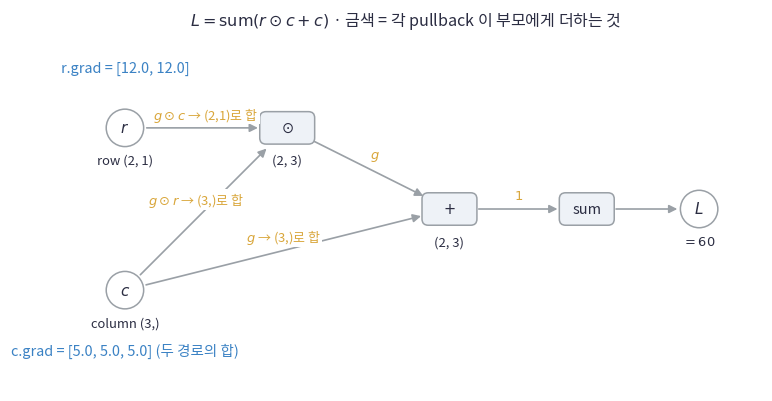

In [14]:
plot_local_rules(rule_row, rule_column, rule_row_grad, rule_column_grad)

🔍 **확인** · `column`은 곱셈과 덧셈 두 곳에 쓰였으므로 두 경로의 기여 $[3,3,3]+[2,2,2]$를 더해 $[5,5,5]$입니다. `row`는 곱셈에서 `column`을 곱한 기울기를 열 방향으로 합쳐 $[12,12]$입니다. 아래 구현의 각 `back`이 이 한 줄들이고, 검산에서 같은 값이 나오는지 봅니다.

In [15]:
def add(a, b):
    a, b = as_node(a), as_node(b)
    def back(g):
        a.grad += sum_to_shape(g, a.data.shape)
        b.grad += sum_to_shape(g, b.data.shape)
    return Node(a.data + b.data, (a, b), back)


def multiply(a, b):
    a, b = as_node(a), as_node(b)
    def back(g):
        a.grad += sum_to_shape(g * b.data, a.data.shape)
        b.grad += sum_to_shape(g * a.data, b.data.shape)
    return Node(a.data * b.data, (a, b), back)


def matmul(a, b):
    a, b = as_node(a), as_node(b)
    if a.data.ndim != 2 or b.data.ndim != 2:
        raise ValueError('이 matmul의 입력은 2차원 행렬 두 개입니다.')
    def back(g):
        a.grad += g @ b.data.T
        b.grad += a.data.T @ g
    return Node(a.data @ b.data, (a, b), back)


def tanh(a):
    a = as_node(a)
    value = np.tanh(a.data)
    def back(g):
        a.grad += g * (1 - value**2)
    return Node(value, (a,), back)


def total_sum(a):
    a = as_node(a)
    def back(g):
        a.grad += np.ones_like(a.data) * g
    return Node(a.data.sum(), (a,), back)

In [16]:
x = Node(3.)
u = x * x
y = u + u
y.backward()
np.testing.assert_allclose([u.data, y.data, x.grad], [9., 18., 12.])
y.backward()
np.testing.assert_allclose(x.grad, 12.)

v = Node(np.array([2., 3.]))
f = v * v + v
f.backward(np.array([.5, -2.]))
np.testing.assert_allclose(v.grad, [2.5, -14.])

row = Node(np.array([[1.], [2.]]))
column = Node(np.array([3., 4., 5.]))
broadcast_output = (row * column + column).sum()
broadcast_output.backward()
np.testing.assert_allclose(row.grad, [[12.], [12.]])
np.testing.assert_allclose(column.grad, [5., 5., 5.])
print('공유 경로·재계산·벡터 seed·양쪽 broadcasting 통과')
np.testing.assert_allclose(row.grad, rule_row_grad); np.testing.assert_allclose(column.grad, rule_column_grad)   # 위 그림과 같은 값

공유 경로·재계산·벡터 seed·양쪽 broadcasting 통과


🔍 **확인** · 공유 경로($x\cdot x$의 12), 두 번 backward해도 같은 값(초기화), 벡터 seed, 양쪽 broadcasting이 모두 손계산과 맞습니다.
같은 $x$가 곱셈의 양쪽 부모에 있어도 두 항을 더해야 합니다. 그래프를 방문하는 횟수와 기울기 기여의 수는 서로 다른 개념입니다.

## 🔍 4. 동일한 MLP를 네 가지 미분으로 검산하기

$H=\tanh(XW_1+b_1)$, $\hat Y=HW_2+b_2$,
$L=\tfrac1{2NK}\sum_{n,k}(\hat Y_{nk}-Y_{nk})^2$를 사용합니다.
$X:(N,D)$, $W_1:(D,H)$, $b_1:(H,)$, $W_2:(H,K)$, $b_2:(K,)$입니다.
전체 원소 평균이므로 출력 쪽 기울기는 $(\hat Y-Y)/(NK)$입니다.

같은 가중치에서 (1) 03번처럼 손으로 쓴 backward, (2) 이 엔진, (3) PyTorch, (4) 중심차분을 비교합니다.

In [17]:
def graph_prediction(X, parameters, matmul_fn=matmul):
    W1, b1, W2, b2 = parameters
    hidden = (matmul_fn(as_node(X), W1) + b1).tanh()
    return matmul_fn(hidden, W2) + b2


def graph_loss(X, Y, parameters, matmul_fn=matmul):
    residual = graph_prediction(X, parameters, matmul_fn) - Y
    return .5 * (residual * residual).mean()


def manual_mlp(X, Y, arrays):
    W1, b1, W2, b2 = arrays
    hidden = np.tanh(X @ W1 + b1)
    prediction = hidden @ W2 + b2
    residual = prediction - Y
    loss = .5 * np.mean(residual**2)
    d_prediction = residual / residual.size
    dW2 = hidden.T @ d_prediction
    db2 = d_prediction.sum(axis=0)
    d_hidden_input = (d_prediction @ W2.T) * (1 - hidden**2)
    dW1 = X.T @ d_hidden_input
    db1 = d_hidden_input.sum(axis=0)
    return loss, [dW1, db1, dW2, db2]

In [18]:
rng = np.random.default_rng(130)
X_check, Y_check = rng.normal(size=(5, 3)), rng.normal(size=(5, 2))
arrays = [rng.normal(size=shape) * .3 for shape in [(3, 4), (4,), (4, 2), (2,)]]
parameters = [Node(value) for value in arrays]
loss_node = graph_loss(X_check, Y_check, parameters)
loss_node.backward()
manual_value, manual_gradients = manual_mlp(X_check, Y_check, arrays)
np.testing.assert_allclose(loss_node.data, manual_value)
engine_errors, numeric_errors = [], []
for parameter, manual_gradient, array in zip(parameters, manual_gradients, arrays):
    engine_errors.append(rel_error(parameter.grad, manual_gradient))
    numeric = numerical_gradient(lambda: manual_mlp(X_check, Y_check, arrays)[0], array)
    numeric_errors.append(rel_error(parameter.grad, numeric))
assert max(engine_errors) < 1e-12 and max(numeric_errors) < 1e-7
print('직접 backward / 중심차분 최대 상대 오차:', max(engine_errors), max(numeric_errors))

직접 backward / 중심차분 최대 상대 오차: 3.6193162287701783e-16 4.1681016385990223e-10


🔍 **확인** · 엔진의 네 파라미터 기울기가 손으로 쓴 backward와 $10^{-12}$ 안에서, 중심차분과 $10^{-7}$ 안에서 같습니다.

### 📎 PyTorch와 같은 값·기울기·한 스텝 비교

`torch.tensor(..., requires_grad=True)`는 기울기를 계산할 파라미터를 만듭니다.
`backward()` 뒤 각 파라미터의 `.grad`를 읽습니다. PyTorch의 파라미터 기울기는 호출 사이에 **누적**되므로 새 스텝에는 `.grad=None` 또는 optimizer의 `zero_grad()`로 초기화합니다.
이 엔진은 `Node.backward` 안에서 초기화한다는 차이가 있습니다.

`torch.no_grad()` 블록은 파라미터 갱신을 다음 계산 그래프와 구분합니다.
`detach()`는 현재 값을 유지하면서 이전 그래프와의 연결을 끊고, `numpy()`는 CPU tensor를 NumPy 배열로 확인하게 합니다.

In [19]:
torch_parameters = [torch.tensor(a, dtype=torch.float64, requires_grad=True) for a in arrays]
tX, tY = torch.tensor(X_check, dtype=torch.float64), torch.tensor(Y_check, dtype=torch.float64)
tW1, tb1, tW2, tb2 = torch_parameters
torch_prediction = torch.tanh(tX @ tW1 + tb1) @ tW2 + tb2
torch_loss = .5 * ((torch_prediction - tY)**2).mean()
torch_loss.backward()
np.testing.assert_allclose(torch_loss.item(), loss_node.data, rtol=1e-12)
torch_errors = [rel_error(node.grad, t.grad.detach().numpy()) for node, t in zip(parameters, torch_parameters)]
assert max(torch_errors) < 1e-12
lr = .07
expected_updates = [a - lr*g for a, g in zip(arrays, manual_gradients)]
with torch.no_grad():
    for t in torch_parameters:
        t -= lr * t.grad
for node, t, expected in zip(parameters, torch_parameters, expected_updates):
    node.data -= lr * node.grad
    np.testing.assert_allclose(node.data, expected, atol=1e-14)
    np.testing.assert_allclose(t.detach().numpy(), expected, atol=1e-14)
    t.grad = None
print('PyTorch 최대 기울기 상대 오차:', max(torch_errors), '네 배열의 SGD 한 스텝 일치')

PyTorch 최대 기울기 상대 오차: 2.386196090606463e-16 네 배열의 SGD 한 스텝 일치


🔍 **확인** · PyTorch의 손실·기울기가 엔진과 같고, 학습률 0.07의 SGD 한 스텝 뒤 네 배열이 세 방법 모두 같습니다.

## 🔑 5. 그래프를 다시 만들며 작은 회귀 모델 학습하기

**이 절에서 가져갈 것:** 학습 스텝은 "현재 파라미터로 그래프를 새로 만든다 → backward로 기울기를 채운다 → 파라미터를 갱신한다"의 반복입니다. 이전 스텝의 그래프는 버립니다. 미분은 자동이지만 모델 구조·손실의 평균 축·학습률은 직접 정합니다.

> **용어** · **동적 그래프(define-by-run)**: 순전파를 실행할 때마다 그래프가 새로 만들어지는 방식. 이 엔진과 PyTorch가 그렇습니다.

학습 관측 64개에서 $y=\sin(\pi x)+\text{잡음}$을 맞춥니다.
매 스텝 `graph_loss`가 현재 파라미터로 새 그래프를 만들고, `backward`가 그 그래프의 기울기를 계산한 뒤 SGD가 갱신합니다.
검증에서는 별도로 생성한 128개 관측의 오차를 읽습니다.

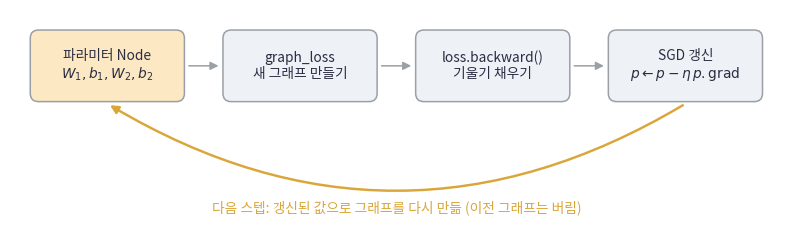

In [20]:
plot_training_cycle()

🔍 **확인** · 파라미터 Node만 스텝을 넘어 살아남고, 손실·은닉값 같은 중간 Node는 스텝마다 새로 만들어집니다. 그래서 갱신은 backward가 끝난 뒤, 다음 그래프를 만들기 전에 합니다. 아래 구현이 이 순환을 코드로 쓴 것입니다.

In [21]:
def fit_graph_mlp(X, Y, hidden_size=12, steps=1800, lr=.1, seed=131, matmul_fn=matmul):
    local_rng = np.random.default_rng(seed)
    D, K = X.shape[1], Y.shape[1]
    values = [local_rng.normal(size=(D, hidden_size)), np.zeros(hidden_size),
              local_rng.normal(size=(hidden_size, K)) * .2, np.zeros(K)]
    params = [Node(value) for value in values]
    history = []
    for step in range(steps):
        loss = graph_loss(X, Y, params, matmul_fn)
        history.append(float(loss.data))
        loss.backward()
        for parameter in params:
            parameter.data -= lr * parameter.grad
    history.append(float(graph_loss(X, Y, params, matmul_fn).data))
    return params, np.array(history)

In [22]:
X_train = np.linspace(-1, 1, 64)[:, None]
Y_train = np.sin(np.pi * X_train) + rng.normal(size=(64, 1)) * .04
X_valid = rng.uniform(-1, 1, size=(128, 1))
Y_valid = np.sin(np.pi * X_valid) + rng.normal(size=(128, 1)) * .04
trained_parameters, train_history = fit_graph_mlp(X_train, Y_train)
valid_prediction = graph_prediction(X_valid, trained_parameters).data
valid_half_mse = .5 * np.mean((valid_prediction - Y_valid)**2)
assert train_history[-1] < .05 * train_history[0]
assert valid_half_mse < .02
print('학습 half-MSE:', train_history[0], '→', train_history[-1], '검증:', valid_half_mse)

학습 half-MSE: 0.7215567955122906 → 0.003792637122729365 검증: 0.004301816888744917


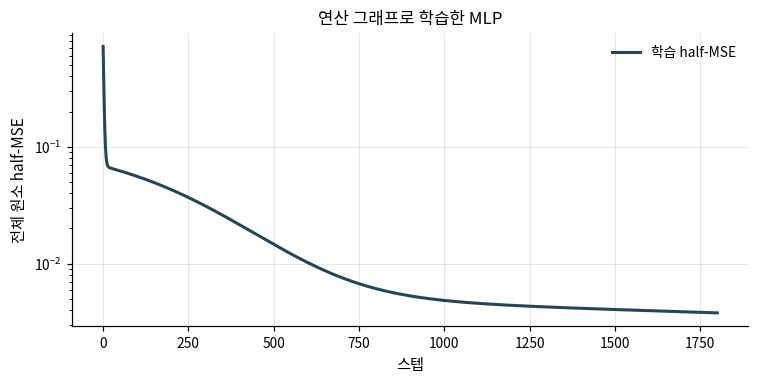

In [23]:
plot_curves(np.arange(len(train_history)), {'학습 half-MSE': train_history}, title='연산 그래프로 학습한 MLP', ylabel='전체 원소 half-MSE', logy=True)

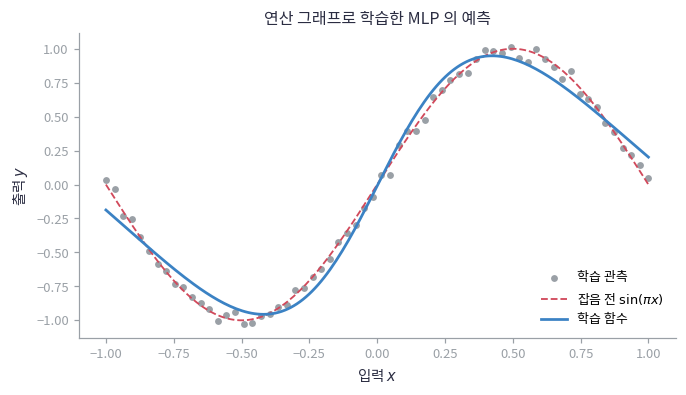

In [24]:
grid = np.linspace(-1, 1, 180)[:, None]
grid_prediction = graph_prediction(grid, trained_parameters).data
plot_fit(X_train.ravel(), Y_train.ravel(), grid.ravel(), grid_prediction.ravel(), np.sin(np.pi * grid).ravel())

🔍 **확인** · 학습 손실이 처음의 5% 아래로 내려가고 검증 half-MSE도 0.02 아래입니다. 파란 학습 함수가 잡음 전의 $\sin(\pi x)$를 따라갑니다. 기울기의 계산을 자동화해도 모델의 구조·손실의 평균 축·학습률은 직접 정합니다.

### 🔍 stop-gradient를 숫자로 확인하기

$x=3$에서 $x\cdot x$와 $x\cdot\operatorname{stopgrad}(x)$의 값은 모두 9입니다.
앞쪽 경로만 미분하는 두 번째 계산의 기울기는 3이고, 양쪽 경로를 미분하면 6입니다.
이 연산은 표현 예측의 교사 타깃과 RL의 고정 타깃을 만들 때 연결됩니다. 값을 복사해 새 Node로 만드는 것이 이 엔진의 해당 동작입니다.

In [25]:
live = Node(3.)
(live * live).backward()
full_gradient = live.grad.copy()
(live * Node(live.data)).backward()
stopped_gradient = live.grad.copy()
pt = torch.tensor(3., dtype=torch.float64, requires_grad=True)
(pt * pt.detach()).backward()
np.testing.assert_allclose([full_gradient, stopped_gradient, pt.grad.item()], [6., 3., 3.])
print('양쪽 경로 / 한쪽 경로:', full_gradient, stopped_gradient)

양쪽 경로 / 한쪽 경로: 6.0 3.0


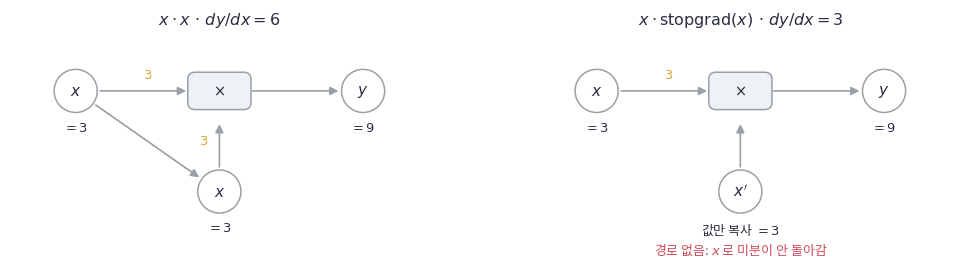

In [26]:
plot_stop_gradient(full_gradient, stopped_gradient)

🔍 **확인** · 오른쪽 그래프에서 복사한 값은 $x$와 연결되어 있지 않아 기울기가 한 경로로만 돌아가 3입니다. PyTorch의 `detach()`도 같은 3을 냅니다.

## ✏️ 6. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · broadcasting 역방향의 두 합 (2절)

기울기 `dY` $(N,D)$에서 $(D,)$ 편향의 기울기와 $(N,1)$ 열벡터의 기울기를 만드는 두 줄을 채우세요.

In [27]:
def exercise_broadcast_grads(dY):
    assert dY.ndim == 2
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: db = 앞 축을 합한 (D,), dcol = 둘째 축을 길이 1로 남기며 합한 (N, 1)
    ### 힌트: dY.sum(axis=0), dY.sum(axis=1, keepdims=True)
    raise NotImplementedError
    return db, dcol

In [28]:
def check_broadcast_grads(candidate):
    db_a, dcol_a = candidate(bc_upstream)
    np.testing.assert_allclose(db_a, [5., 7., 9.]); np.testing.assert_allclose(dcol_a, [[6.], [15.]])            # 2절 손계산
    G_c = np.random.default_rng(132).normal(size=(4, 5))
    db_c, dcol_c = candidate(G_c)
    np.testing.assert_allclose(db_c, sum_to_shape(G_c, (5,))); np.testing.assert_allclose(dcol_c, sum_to_shape(G_c, (4, 1)))
    print("broadcasting 역방향: 손계산·sum_to_shape 와 일치합니다.")

run_check(check_broadcast_grads, exercise_broadcast_grads, hint="db = dY.sum(axis=0); dcol = dY.sum(axis=1, keepdims=True)")

☐ exercise_broadcast_grads: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: db = dY.sum(axis=0); dcol = dY.sum(axis=1, keepdims=True)


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
db = dY.sum(axis=0)
dcol = dY.sum(axis=1, keepdims=True)
```

</details>

### ✏️ 연습 B · 곱셈의 pullback (3절)

$Y=A\odot B$에서 상류 `g`와 두 입력 값으로 각 입력의 기울기를 원래 모양으로 만드는 두 줄을 채우세요.

In [29]:
def exercise_multiply_back(g, a_data, b_data):
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: da = g ⊙ b_data 를 a_data 의 모양으로 합친 것, db = g ⊙ a_data 를 b_data 의 모양으로 합친 것
    ### 힌트: sum_to_shape(g * b_data, a_data.shape)
    raise NotImplementedError
    return da, db

In [30]:
def check_multiply_back(candidate):
    da_a, db_a = candidate(np.ones((2, 3)), rule_row, rule_column)
    np.testing.assert_allclose(da_a, [[12.], [12.]]); np.testing.assert_allclose(db_a, [3., 3., 3.])               # 3절 그림의 곱셈 경로
    rng_c = np.random.default_rng(133)
    a_c, b_c, g_c = rng_c.normal(size=(3, 1)), rng_c.normal(size=(3, 4)), rng_c.normal(size=(3, 4))
    na, nb = Node(a_c), Node(b_c)
    multiply(na, nb).backward(g_c)
    da_c, db_c = candidate(g_c, a_c, b_c)
    np.testing.assert_allclose(da_c, na.grad); np.testing.assert_allclose(db_c, nb.grad)                           # 엔진의 multiply 와 같음
    print("곱셈 pullback: 손계산·엔진과 일치합니다.")

run_check(check_multiply_back, exercise_multiply_back, hint="da = sum_to_shape(g * b_data, a_data.shape); db = sum_to_shape(g * a_data, b_data.shape)")

☐ exercise_multiply_back: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: da = sum_to_shape(g * b_data, a_data.shape); db = sum_to_shape(g * a_data, b_data.shape)


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
da = sum_to_shape(g * b_data, a_data.shape)
db = sum_to_shape(g * a_data, b_data.shape)
```

</details>

### ✏️ 연습 C · tanh 연산 노드 만들기 (3절)

값·부모는 써 두었습니다. `back` 안에서 부모의 `grad`에 국소 미분을 곱한 기울기를 **더하는** 한 줄을 채우세요.

In [31]:
def exercise_tanh_node(a):
    a = as_node(a)
    value = np.tanh(a.data)
    def back(g):
        ### 이 주석 아래에 다음을 구현하세요.
        ### 구현할 내용: a.grad 에 g ⊙ (1 − value²) 를 더합니다 (= 이 아니라 +=)
        ### 힌트: 3절 tanh 의 back 한 줄입니다.
        raise NotImplementedError
    return Node(value, (a,), back)

In [32]:
def check_tanh_node(candidate):
    leaf = Node(np.array([0.5, -1., 2.]))
    out = candidate(leaf)
    assert isinstance(out, Node) and out.parents == (leaf,)
    out.backward(np.array([1., 2., -1.]))
    np.testing.assert_allclose(leaf.grad, np.array([1., 2., -1.]) * (1 - np.tanh(leaf.data) ** 2))                 # 국소 미분
    shared = Node(np.array([0.3, 0.7]))
    (candidate(shared) + candidate(shared)).backward(np.ones(2))
    np.testing.assert_allclose(shared.grad, 2 * (1 - np.tanh(shared.data) ** 2))                                   # 두 경로면 더해짐 (+=)
    print("tanh 노드: 국소 미분과 누적이 맞습니다.")

run_check(check_tanh_node, exercise_tanh_node, hint="a.grad += g * (1 - value ** 2)")

☐ exercise_tanh_node: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: a.grad += g * (1 - value ** 2)


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
a.grad += g * (1 - value ** 2)
```

</details>

### ✏️ 연습 D · 손실의 출력 쪽 기울기 (4절)

$L=\tfrac12\,\mathrm{mean}((\hat Y-Y)^2)$에서 $\partial L/\partial\hat Y$를 만드는 한 줄을 채우세요. 전체 원소 평균이라 원소 수로 나눕니다.

In [33]:
def exercise_output_grad(prediction, Y):
    assert prediction.shape == Y.shape
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: d_prediction = (prediction − Y) / 전체 원소 수
    ### 힌트: prediction.size 가 N·K 입니다.
    raise NotImplementedError
    return d_prediction

In [34]:
def check_output_grad(candidate):
    P_c, Y_c = np.array([[1., 2.], [3., 4.]]), np.array([[0., 2.], [1., 1.]])
    np.testing.assert_allclose(candidate(P_c, Y_c), [[0.25, 0.], [0.5, 0.75]])                                     # 손계산: 잔차 / 4
    numeric_c = numerical_gradient(lambda: 0.5 * np.mean((P_c - Y_c) ** 2), P_c)
    np.testing.assert_allclose(candidate(P_c, Y_c), numeric_c, atol=1e-8)                                          # 중심차분
    print("출력 쪽 기울기: 손계산·중심차분과 일치합니다.")

run_check(check_output_grad, exercise_output_grad, hint="d_prediction = (prediction - Y) / prediction.size")

☐ exercise_output_grad: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: d_prediction = (prediction - Y) / prediction.size


False

📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
d_prediction = (prediction - Y) / prediction.size
```

</details>

### 🔍 완성 예제 · 새 행렬곱을 실제 MLP에 넣기

아래 검사기는 후보 행렬곱을 사각 행렬·공유 입력·반복 backward·양쪽 부모·MLP 전체에 실제로 넣어 봅니다. 본문의 `matmul`로 통과시킨 뒤, `fit_graph_mlp(..., hidden_size=6)`로 너비를 바꾸어 학습해 봅니다.

In [35]:
def check_matmul(candidate):
    local_rng = np.random.default_rng(137)
    for N, D, K in [(2, 3, 4), (4, 2, 1)]:
        a, b = Node(local_rng.normal(size=(N, D))), Node(local_rng.normal(size=(D, K)))
        G = local_rng.normal(size=(N, K))
        output = candidate(a, b)
        assert isinstance(output, Node) and output.data.shape == (N, K)
        np.testing.assert_allclose(output.data, a.data @ b.data)
        output.backward(G)
        np.testing.assert_allclose(a.grad, G @ b.data.T, atol=1e-12)
        np.testing.assert_allclose(b.grad, a.data.T @ G, atol=1e-12)
    shared = Node(local_rng.normal(size=(3, 3)))
    G = local_rng.normal(size=(3, 3))
    candidate(shared, shared).backward(G)
    np.testing.assert_allclose(shared.grad, G @ shared.data.T + shared.data.T @ G, atol=1e-12)
    # 서로 다른 두 연산에서 같은 입력을 사용하면 모든 기여를 누적합니다.
    a = Node(local_rng.normal(size=(2, 3)))
    b, c = Node(local_rng.normal(size=(3, 2))), Node(local_rng.normal(size=(3, 2)))
    G = local_rng.normal(size=(2, 2))
    branched = candidate(a, b) + candidate(a, c)
    for _ in range(2):
        branched.backward(G)
        np.testing.assert_allclose(a.grad, G @ (b.data+c.data).T, atol=1e-12)
        np.testing.assert_allclose(b.grad, a.data.T @ G, atol=1e-12)
        np.testing.assert_allclose(c.grad, a.data.T @ G, atol=1e-12)
    # 오른쪽 입력에도 앞선 연산이 있으면 그 부모까지 역전파해야 합니다.
    root_b = Node(local_rng.normal(size=(3, 2)))
    candidate(a, root_b * 2.).backward(G)
    np.testing.assert_allclose(root_b.grad, 2*a.data.T @ G, atol=1e-12)
    X, Y = local_rng.normal(size=(4, 3)), local_rng.normal(size=(4, 2))
    values = [local_rng.normal(size=s) * .2 for s in [(3, 5), (5,), (5, 2), (2,)]]
    params = [Node(value) for value in values]
    loss = graph_loss(X, Y, params, matmul_fn=candidate)
    loss.backward()
    reference_loss, reference_grads = manual_mlp(X, Y, values)
    np.testing.assert_allclose(loss.data, reference_loss, atol=1e-12)
    for p, reference in zip(params, reference_grads):
        np.testing.assert_allclose(p.grad, reference, atol=1e-11)
    return '통과: 사각 행렬·공유 분기·반복 backward·양쪽 부모·MLP 전체 기울기'

In [36]:
print(check_matmul(matmul))
smaller_parameters, smaller_history = fit_graph_mlp(X_train, Y_train, hidden_size=6)
smaller_valid = .5 * np.mean((graph_prediction(X_valid, smaller_parameters).data - Y_valid)**2)
print('hidden=6 학습 / 검증 half-MSE:', smaller_history[-1], smaller_valid)

통과: 사각 행렬·공유 분기·반복 backward·양쪽 부모·MLP 전체 기울기


hidden=6 학습 / 검증 half-MSE: 0.006918263554772796 0.007321249042379014


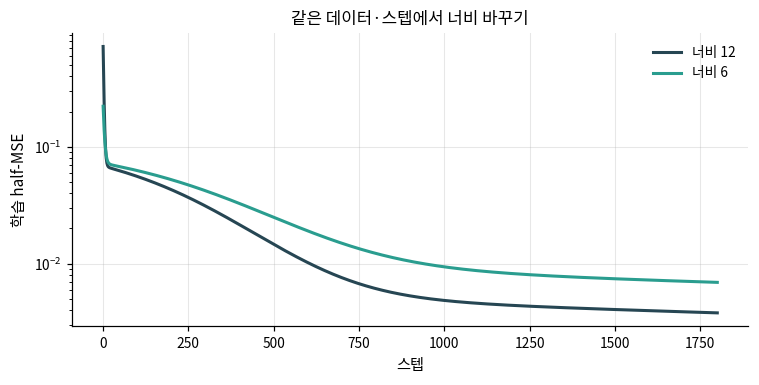

In [37]:
plot_curves(np.arange(len(train_history)), {'너비 12': train_history, '너비 6': smaller_history},
            title='같은 데이터·스텝에서 너비 바꾸기', ylabel='학습 half-MSE', logy=True)

### ✏️ 준비도 질문 · 다음으로 가기 전, 다섯 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- 공유 Node를 한 번 방문하면서도 여러 경로의 기울기를 합하는 이유를 설명할 수 있나요? → 1·3절
- `sum_to_shape`의 두 종류 합을 각각 작은 배열로 확인할 수 있나요? → 2절
- 벡터 출력의 `seed`를 바꾸면 어떤 스칼라 목적의 기울기가 되는지 쓸 수 있나요? → 1·3절
- PyTorch와 이 엔진의 기울기 초기화 위치를 찾고 한 스텝을 대조할 수 있나요? → 4절
- 새 연산에 값·부모·VJP를 붙여 전체 MLP 검산까지 통과시킬 수 있나요? → 3절

다음 [14 손실·정규화](14_losses_regularization.ipynb)에서는 계산할 목적을 바꿉니다.

📎 공식 API 참고: [PyTorch의 자동미분 안내](https://docs.pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html).
이 노트북의 NumPy 엔진은 본문에 제시한 연산 범위와 초기화 규약을 따릅니다.